In [6]:
# %% [markdown]
# # INFO-F-422 Project: EMG-based Hand Pose Estimation (Guided Gestures)
#
# **Team:** [Your Team Name/Number]
# **Members:** [Your Names]
#
# This notebook implements the baseline approach for predicting hand joint angles from sEMG signals using the guided gestures dataset.

# %%
# Core Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import pickle # To save models/results if needed

# Scikit-learn Modules
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_validate, train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_regression, SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR # Example alternative

# Helper for timing
from contextlib import contextmanager

# Configure visualizations
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define a timing context manager for convenience
@contextmanager
def timer(label: str):
    start = time.time()
    print(f"{label}...")
    yield
    end = time.time()
    print(f"{label} done in {end - start:.2f} seconds.\n")

In [7]:


# %% [markdown]
# ## 1. Load Data
#
# Load the guided gestures dataset files:
# - `guided_dataset_X.npy`: Training/Validation sEMG data (sessions, electrodes, time)
# - `guided_dataset_y.npy`: Training/Validation joint angle data (sessions, joints, time)
# - `guided_testset_X.npy`: Test sEMG data (sessions, windows, electrodes, time_in_window) - *Note: We'll handle the test set structure later when predicting for the competition.*

# %%
# File paths (assuming data is in the same directory as the notebook)
X_TRAIN_VAL_PATH = "guided_dataset_X.npy"
Y_TRAIN_VAL_PATH = "guided_dataset_y.npy"
X_TEST_PATH = "guided_testset_X.npy" # We won't use this heavily until Objective 7

# Load the training/validation data
X_train_val_raw = np.load(X_TRAIN_VAL_PATH)
y_train_val_raw = np.load(Y_TRAIN_VAL_PATH)

# Load the test data structure description (we need shape info)
X_test_raw_info = np.load(X_TEST_PATH, mmap_mode='r') # Use mmap_mode for large files if needed

# Print shapes to verify
print("Raw Training/Validation Data Shapes:")
print(f"X_train_val_raw: {X_train_val_raw.shape}") # (session, electrode, time) -> (5, 8, 230000)
print(f"y_train_val_raw: {y_train_val_raw.shape}") # (session, joint, time) -> (5, 51, 230000)
print("\nRaw Test Data Shape (for info):")
print(f"X_test_raw_info: {X_test_raw_info.shape}") # (session, window_idx, electrode, time_in_window) -> (5, 332, 8, 500)

# Constants derived from data
N_SESSIONS_TRAIN_VAL = X_train_val_raw.shape[0]
N_ELECTRODES = X_train_val_raw.shape[1]
N_TIME_POINTS_TRAIN_VAL = X_train_val_raw.shape[2]
N_JOINTS = y_train_val_raw.shape[1]

print(f"\nNumber of Training/Validation Sessions: {N_SESSIONS_TRAIN_VAL}")
print(f"Number of Electrodes: {N_ELECTRODES}")
print(f"Number of Time Points per Session: {N_TIME_POINTS_TRAIN_VAL}")
print(f"Number of Joints: {N_JOINTS}")


Raw Training/Validation Data Shapes:
X_train_val_raw: (5, 8, 230000)
y_train_val_raw: (5, 51, 230000)

Raw Test Data Shape (for info):
X_test_raw_info: (5, 332, 8, 500)

Number of Training/Validation Sessions: 5
Number of Electrodes: 8
Number of Time Points per Session: 230000
Number of Joints: 51


In [8]:


# %% [markdown]
# ## 2. (Optional) Signal Filtering
#
# *This step is optional but recommended.* Common filtering includes band-pass filtering (e.g., 20-450 Hz) to remove noise and DC offset removal. For simplicity in this initial baseline, we will **skip explicit filtering**. However, note that some features (like ZC) might be sensitive to baseline wander if not removed. Normalization (like StandardScaler later) helps mitigate some scaling issues.
#
# *If you wanted to add filtering, you would apply it here to `X_train_val_raw` before windowing.*
# ```python
# # Example (requires scipy):
# # from scipy.signal import butter, filtfilt
# #
# # def butter_bandpass(lowcut, highcut, fs, order=5):
# #     nyq = 0.5 * fs
# #     low = lowcut / nyq
# #     high = highcut / nyq
# #     b, a = butter(order, [low, high], btype='band')
# #     return b, a
# #
# # def bandpass_filter(data, lowcut, highcut, fs, order=5):
# #     b, a = butter_bandpass(lowcut, highcut, fs, order=order)
# #     # Apply filter along the time axis (axis=-1)
# #     y = filtfilt(b, a, data, axis=-1)
# #     return y
# #
# # FS = 1024 # Sampling frequency from documentation
# # LOWCUT = 20
# # HIGHCUT = 450
# #
# # X_train_val_filtered = np.zeros_like(X_train_val_raw)
# # for i in range(N_SESSIONS_TRAIN_VAL):
# #     # Remove DC offset (mean) per channel
# #     dc_removed = X_train_val_raw[i] - np.mean(X_train_val_raw[i], axis=-1, keepdims=True)
# #     # Apply bandpass filter
# #     X_train_val_filtered[i] = bandpass_filter(dc_removed, LOWCUT, HIGHCUT, FS)
# #
# # X_train_val_to_window = X_train_val_filtered
# # print("Applied DC offset removal and bandpass filtering.")
# ```
# For now, we proceed without filtering:

# %%
X_train_val_to_window = X_train_val_raw
print("Skipping explicit signal filtering for this baseline.")

Skipping explicit signal filtering for this baseline.


In [9]:


# %% [markdown]
# ## 3. Dataset Preparation: Overlapping Windows (Objective 2)
#
# We need to segment the continuous sEMG and joint angle data into overlapping windows.
# - Window size `k = 500` samples (as specified).
# - Overlap: We choose an overlap percentage (e.g., 50% or 75%). A higher overlap increases the dataset size but also computational cost. Let's start with 50%.
# - Target `y` for a window: The joint angles at the **end** of the corresponding sEMG window `[t-k+1, t]` will be predicted. So, the target `y` for the window ending at time `t` is `y[:, :, t]`.

# %%
# Windowing Parameters
WINDOW_SIZE = 500  # k
OVERLAP_PERCENTAGE = 0.50 # Start with 50%

step = int(WINDOW_SIZE * (1 - OVERLAP_PERCENTAGE))
if step == 0:
    raise ValueError("Overlap percentage cannot be 100%")
print(f"Window Size (k): {WINDOW_SIZE}")
print(f"Overlap: {OVERLAP_PERCENTAGE*100:.0f}%")
print(f"Step Size: {step}")

# %%
def create_overlapping_windows(X_raw, y_raw, window_size, step):
    """
    Creates overlapping windows for EMG (X) and corresponding target joint angles (y).

    Args:
        X_raw (np.ndarray): Raw EMG data (n_sessions, n_electrodes, n_timepoints).
        y_raw (np.ndarray): Raw joint angle data (n_sessions, n_joints, n_timepoints).
        window_size (int): The size of each window (k).
        step (int): The step size between the start of consecutive windows.

    Returns:
        tuple: (X_windowed, y_windowed, groups)
            X_windowed (np.ndarray): Windowed EMG data (n_windows, n_electrodes, window_size).
            y_windowed (np.ndarray): Corresponding target joint angles (n_windows, n_joints).
            groups (np.ndarray): Group label (session index) for each window (n_windows,).
    """
    n_sessions = X_raw.shape[0]
    n_electrodes = X_raw.shape[1]
    n_timepoints = X_raw.shape[2]
    n_joints = y_raw.shape[1]

    X_windowed_list = []
    y_windowed_list = []
    groups_list = []

    for session_idx in range(n_sessions):
        session_X = X_raw[session_idx] # (n_electrodes, n_timepoints)
        session_y = y_raw[session_idx] # (n_joints, n_timepoints)

        start_indices = np.arange(0, n_timepoints - window_size + 1, step)

        for start_idx in start_indices:
            end_idx = start_idx + window_size
            # EMG window: from start_idx to end_idx (exclusive of end_idx if numpy slicing)
            # Adjusting to include start_idx to end_idx-1, which is 'window_size' points
            window_X = session_X[:, start_idx:end_idx]

            # Target y: joint angles at the *end* of the window (time index end_idx - 1)
            target_y = session_y[:, end_idx - 1]

            X_windowed_list.append(window_X)
            y_windowed_list.append(target_y)
            groups_list.append(session_idx) # Store the session index for GroupKFold

        print(f"Session {session_idx}: Created {len(start_indices)} windows.")

    X_windowed = np.stack(X_windowed_list) # Shape: (total_windows, n_electrodes, window_size)
    y_windowed = np.stack(y_windowed_list) # Shape: (total_windows, n_joints)
    groups = np.array(groups_list)          # Shape: (total_windows,)

    return X_windowed, y_windowed, groups

# %%
# Create the windowed dataset
with timer("Creating overlapping windows"):
    X_windowed, y_windowed, groups = create_overlapping_windows(
        X_train_val_to_window, y_train_val_raw, WINDOW_SIZE, step
    )

print("\nWindowed Data Shapes:")
print(f"X_windowed: {X_windowed.shape}")
print(f"y_windowed: {y_windowed.shape}")
print(f"Groups: {groups.shape}")
print(f"Unique groups (sessions): {np.unique(groups)}")



Window Size (k): 500
Overlap: 50%
Step Size: 250
Creating overlapping windows...
Session 0: Created 919 windows.
Session 1: Created 919 windows.
Session 2: Created 919 windows.
Session 3: Created 919 windows.
Session 4: Created 919 windows.
Creating overlapping windows done in 0.20 seconds.


Windowed Data Shapes:
X_windowed: (4595, 8, 500)
y_windowed: (4595, 51)
Groups: (4595,)
Unique groups (sessions): [0 1 2 3 4]


In [10]:

# %% [markdown]
# ## 4. Custom Feature Extractor (Baseline - Objective 4)
#
# Create a Scikit-learn compatible transformer (`BaseEstimator`, `TransformerMixin`) to extract the time-domain features specified in Table 1, plus the requested WL (Waveform Length) and SSC (Slope Sign Changes).
#
# **Features:**
# 1.  **MAV** (Mean Absolute Value)
# 2.  **RMS** (Root Mean Square)
# 3.  **Variance** (Var)
# 4.  **STD** (Standard Deviation)
# 5.  **ZC** (Zero Crossing) - Requires a threshold, typically near zero.
# 6.  **MPR** (Myopulse Percentage Rate) - Requires a threshold `σ`. We'll define `σ` as the standard deviation of the signal *within the window*.
# 7.  **WL** (Waveform Length) - Sum of absolute differences between consecutive samples.
# 8.  **SSC** (Slope Sign Changes) - Count of times the slope of the signal changes sign. Requires a threshold to avoid noise.

# %%
class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Extracts time-domain features from EMG windows.

    Args:
        zc_threshold (float): Threshold for detecting zero crossings.
        ssc_threshold (float): Threshold for detecting slope sign changes.
        selected_features (list, optional): List of feature names to compute.
                                            Defaults to all defined features.
    """
    def __init__(self, zc_threshold=1e-5, ssc_threshold=1e-5, selected_features=None):
        self.zc_threshold = zc_threshold
        self.ssc_threshold = ssc_threshold
        self.all_feature_names = ['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR', 'WL', 'SSC']
        if selected_features is None:
            self.selected_features = self.all_feature_names
        else:
            # Validate selected features
            if not all(f in self.all_feature_names for f in selected_features):
                raise ValueError(f"Invalid feature names in selected_features. "
                                 f"Allowed features: {self.all_feature_names}")
            self.selected_features = selected_features

    def fit(self, X, y=None):
        # This transformer doesn't need fitting
        return self

    def transform(self, X):
        """
        Transforms the windowed EMG data into features.

        Args:
            X (np.ndarray): Windowed EMG data (n_windows, n_electrodes, window_size).

        Returns:
            np.ndarray: Feature matrix (n_windows, n_electrodes * n_selected_features).
        """
        n_windows, n_electrodes, window_size = X.shape
        n_selected = len(self.selected_features)
        features = np.zeros((n_windows, n_electrodes * n_selected))

        for i in range(n_windows):
            window_features = []
            for j in range(n_electrodes):
                channel_data = X[i, j, :]
                channel_features = []

                # Calculate basic stats needed for multiple features
                mav = np.mean(np.abs(channel_data))
                rms = np.sqrt(np.mean(channel_data**2))
                var = np.var(channel_data)
                std = np.sqrt(var) # Or np.std(channel_data)

                if 'MAV' in self.selected_features:
                    channel_features.append(mav)
                if 'RMS' in self.selected_features:
                    channel_features.append(rms)
                if 'Var' in self.selected_features:
                    channel_features.append(var)
                if 'STD' in self.selected_features:
                    channel_features.append(std)

                # Zero Crossing (ZC)
                if 'ZC' in self.selected_features:
                    zc = np.sum(np.diff(np.sign(channel_data - self.zc_threshold)) != 0) / 2
                    # Alternative: count sign changes around 0 after removing mean?
                    # zc = np.sum(np.abs(np.diff(np.sign(channel_data))) > 1) # More robust maybe
                    # Let's use a common definition checking crossing threshold
                    zc_count = 0
                    for k in range(window_size - 1):
                         if ((channel_data[k] > self.zc_threshold and channel_data[k+1] < self.zc_threshold) or \
                            (channel_data[k] < self.zc_threshold and channel_data[k+1] > self.zc_threshold)):
                             #and np.abs(channel_data[k] - channel_data[k+1]) >= self.zc_threshold * 2): # Optional: ensure it's not just noise around threshold
                            zc_count += 1
                    channel_features.append(zc_count)

                # Myopulse Percentage Rate (MPR)
                if 'MPR' in self.selected_features:
                    # Use window's STD as threshold σ, avoid division by zero if std is ~0
                    threshold_mpr = std if std > 1e-9 else 1e-9
                    mpr = np.mean(np.abs(channel_data) > threshold_mpr) # Rate is mean of indicator
                    channel_features.append(mpr)

                # Waveform Length (WL)
                if 'WL' in self.selected_features:
                    wl = np.sum(np.abs(np.diff(channel_data)))
                    channel_features.append(wl)

                # Slope Sign Changes (SSC)
                if 'SSC' in self.selected_features:
                    diff_sig = np.diff(channel_data)
                    ssc_count = 0
                    for k in range(len(diff_sig) - 1):
                        if ((diff_sig[k] > self.ssc_threshold and diff_sig[k+1] < -self.ssc_threshold) or \
                           (diff_sig[k] < -self.ssc_threshold and diff_sig[k+1] > self.ssc_threshold)):
                             ssc_count += 1
                    # Alternative from user prompt (might be sensitive):
                    # diff1 = np.diff(channel_data)
                    # diff2 = np.diff(channel_data, n=2)
                    # ssc = np.sum((diff1[:-1] * diff2) > 0) # This definition seems different from literature? Checking sign *product*
                    # Let's stick to the common definition counting sign changes with threshold
                    channel_features.append(ssc_count)

                window_features.extend(channel_features) # Add features for this channel

            features[i, :] = window_features # Assign features for this window

        # Handle potential NaNs or Infs that might arise from edge cases
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

        return features

    def get_feature_names_out(self, input_features=None):
        """Returns feature names based on electrodes and selected features."""
        feature_names = []
        for j in range(N_ELECTRODES): # Assumes N_ELECTRODES is accessible or passed
            for feature_name in self.selected_features:
                feature_names.append(f"Elec{j+1}_{feature_name}")
        return feature_names

# %%
# Test the feature extractor
with timer("Testing Feature Extractor"):
    feature_extractor = EMGFeatureExtractor()
    X_features = feature_extractor.fit_transform(X_windowed)

print("Feature Matrix Shape:")
print(f"X_features: {X_features.shape}") # Should be (n_windows, n_electrodes * n_features)

# Verify number of features
n_expected_features = N_ELECTRODES * len(feature_extractor.selected_features)
print(f"Expected number of features per window: {n_expected_features}")
assert X_features.shape[1] == n_expected_features, "Feature dimension mismatch!"

# Get feature names
feature_names = feature_extractor.get_feature_names_out()
print(f"\nGenerated {len(feature_names)} feature names. Examples:")
print(feature_names[:5])
print(feature_names[-5:])



Testing Feature Extractor...
Testing Feature Extractor done in 104.10 seconds.

Feature Matrix Shape:
X_features: (4595, 64)
Expected number of features per window: 64

Generated 64 feature names. Examples:
['Elec1_MAV', 'Elec1_RMS', 'Elec1_Var', 'Elec1_STD', 'Elec1_ZC']
['Elec8_STD', 'Elec8_ZC', 'Elec8_MPR', 'Elec8_WL', 'Elec8_SSC']


Using GroupKFold with 5 splits (Leave-One-Session-Out).
Group labels for CV: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] ...


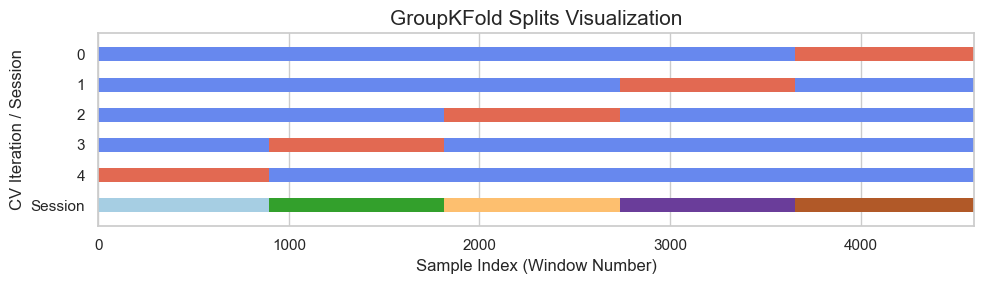

In [11]:

# %% [markdown]
# ## 5. Cross-Validation Strategy (Objective 3)
#
# **Strategy:** Use `GroupKFold` with session IDs as groups.
#
# **Justification:**
# 1.  **Prevents Data Leakage:** Ensures that all data (all windows) from a single recording session are either entirely in the training set or entirely in the validation set for each fold. This is crucial because data points within the same session are likely correlated due to consistent sensor placement, participant state, and potentially similar movement patterns performed close in time. Simple KFold or ShuffleSplit would randomly mix windows from the same session into train and validation, leading to overly optimistic performance estimates because the model would be validated on data very similar (temporally close or from the same recording setup) to data it was trained on.
# 2.  **Simulates Realistic Scenario:** In a real-world application, a model trained on sessions from one day (or set of conditions) might need to generalize to a new session on another day. `GroupKFold` mimics this by testing the model's ability to generalize across sessions.
# 3.  **Uses All Data:** Like KFold, it allows using all data for both training and validation across the different folds.
#
# We have 5 sessions, so `n_splits=5` is a natural choice for `GroupKFold`, leading to a Leave-One-Session-Out cross-validation.

# %%
N_SPLITS = N_SESSIONS_TRAIN_VAL # Use Leave-One-Session-Out
cv_strategy = GroupKFold(n_splits=N_SPLITS)

print(f"Using GroupKFold with {N_SPLITS} splits (Leave-One-Session-Out).")
print("Group labels for CV:", groups[:20], "...") # Show example group labels

# Visualize the splits (optional but good for understanding)
def plot_cv_indices(cv, X, y, group, n_splits):
    """Creates a sample plot for training/validation indices"""
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    cmap_data = plt.cm.Paired
    cmap_cv = plt.cm.coolwarm
    for i, (train_idx, test_idx) in enumerate(cv.split(X, y, group)):
        # fill the train/test groups with colors
        indices = np.array([np.nan] * len(X))
        indices[test_idx] = 1
        indices[train_idx] = 0
        # Visualize the results
        ax.scatter(range(len(indices)), [i + .5] * len(indices),
                   c=indices, marker='_', lw=10, cmap=cmap_cv,
                   vmin=-.2, vmax=1.2)

    # Plot the data classes at the end
    ax.scatter(range(len(X)), [i + 1.5] * len(X),
               c=group, marker='_', lw=10, cmap=cmap_data)

    # Formatting
    yticklabels = list(range(n_splits)) + ['Session']
    ax.set(yticks=np.arange(n_splits + 1) + .5, yticklabels=yticklabels,
           xlabel='Sample Index (Window Number)', ylabel="CV Iteration / Session",
           ylim=[n_splits + 1.2, -.2], xlim=[0, len(y)])
    ax.set_title('GroupKFold Splits Visualization', fontsize=15)
    plt.tight_layout()
    plt.show()

# Plot for our setup
plot_cv_indices(cv_strategy, X_features, y_windowed, groups, N_SPLITS)

# %% [markdown]
# The plot shows that for each CV iteration (rows 0-4), one entire session (indicated by color in the bottom row 'Session') is held out as the validation set (red), while the other sessions are used for training (blue). This confirms our strategy prevents session-based data leakage.


Cross-validating Ridge...
Cross-validating Ridge done in 103.72 seconds.

Cross-validating RandomForest...
Cross-validating RandomForest done in 122.12 seconds.


Cross-Validation Performance Results:

--- Ridge ---
  RMSE: 7.2786 +/- 0.5675
  NMSE: 0.2644 +/- 0.0463
  R2 Score: 0.5826 +/- 0.0839
  Avg Fit Time: 70.58s
  Avg Score Time: 16.74s

--- RandomForest ---
  RMSE: 4.5659 +/- 0.7359
  NMSE: 0.1063 +/- 0.0381
  R2 Score: 0.7108 +/- 0.0757
  Avg Fit Time: 97.71s
  Avg Score Time: 19.37s

--- Summary Table ---
       Model  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std  R2_mean  R2_std  FitTime
       Ridge     7.2786    0.5675     0.2644    0.0463   0.5826  0.0839  70.5766
RandomForest     4.5659    0.7359     0.1063    0.0381   0.7108  0.0757  97.7062
Extracting features and scaling for Importance Analysis...
Extracting features and scaling for Importance Analysis done in 49.07 seconds.

Training RandomForest on full data for Importance Analysis...
Training RandomForest on full data 

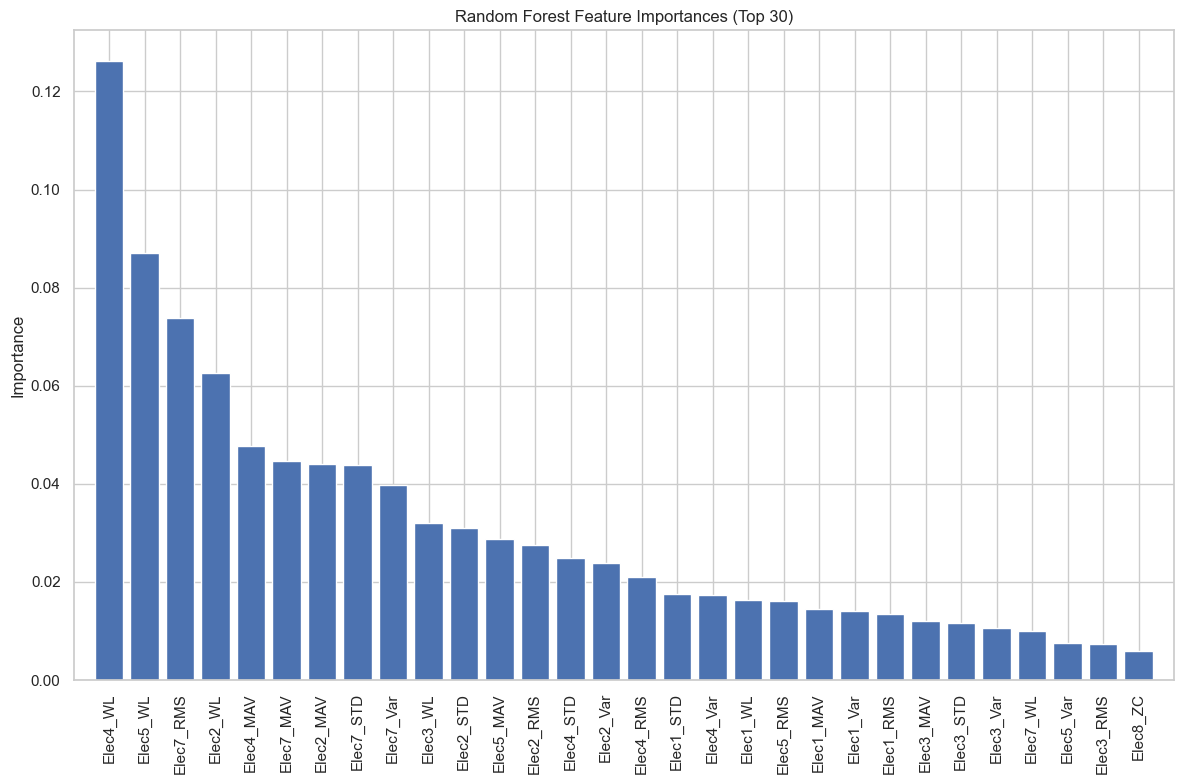

In [12]:

# %% [markdown]
# ## 6. Baseline Model Training and Evaluation (Objective 4)
#
# We will:
# 1.  Define performance metrics: RMSE and NMSE.
# 2.  Select two regression models (e.g., `Ridge`, `RandomForestRegressor`).
# 3.  Create a pipeline: `EMGFeatureExtractor` -> `StandardScaler` -> `Regressor`.
# 4.  Evaluate models using `cross_validate` with our `GroupKFold` strategy.
# 5.  Compare performance and feature importances (for RF).

# %%
# Define Performance Metrics

def root_mean_squared_error(y_true, y_pred):
    """Calculate RMSE across all dimensions."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

def normalized_mean_squared_error(y_true, y_pred):
    """Calculate NMSE across all dimensions."""
    # Ensure y_true and y_pred are numpy arrays
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.shape != y_pred.shape:
        raise ValueError("Input arrays y_true and y_pred must have the same shape.")
    if y_true.ndim == 1: # Handle case if only one joint is predicted (unlikely here)
        y_true = y_true.reshape(-1, 1)
        y_pred = y_pred.reshape(-1, 1)

    # Calculate numerator: MSE summed over all dimensions and samples
    numerator = np.sum((y_true - y_pred)**2)

    # Calculate denominator: Variance summed over all dimensions and samples
    # Mean of each joint angle across all test observations
    mean_y_true_per_joint = np.mean(y_true, axis=0) # Shape (n_joints,)
    # Denominator uses variance relative to the mean of each joint angle
    denominator = np.sum((y_true - mean_y_true_per_joint)**2)

    if denominator == 0:
        # Handle case where true values are constant
        return np.inf if numerator > 1e-9 else 0.0

    return numerator / denominator

# Create scorers for cross-validation
scorers = {
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'nmse': make_scorer(normalized_mean_squared_error, greater_is_better=False),
    'r2': make_scorer(r2_score) # R2 score is also informative
}

# %%
# Select Models
model_ridge = Ridge(alpha=1.0) # Basic regularized linear model
model_rf = RandomForestRegressor(
    n_estimators=100, # Number of trees
    max_depth=15,     # Limit tree depth to prevent overfitting
    n_jobs=-1,        # Use all available CPU cores
    random_state=42,  # For reproducibility
    max_features=0.33 # Consider only a subset of features for each split
)

models_to_evaluate = {
    "Ridge": model_ridge,
    "RandomForest": model_rf
}

# %%
# Evaluate models using Cross-Validation
cv_results = {}

for model_name, model in models_to_evaluate.items():
    with timer(f"Cross-validating {model_name}"):
        # Create the full pipeline for this model
        pipeline = Pipeline([
            ('feature_extraction', EMGFeatureExtractor()), # Use default features for now
            ('scaling', StandardScaler()),
            ('regression', model)
        ])

        # Perform cross-validation
        # Pass the *original* windowed data (X_windowed) here.
        # The pipeline handles feature extraction and scaling internally for each fold.
        scores = cross_validate(
            pipeline,
            X_windowed,         # Input to the pipeline
            y_windowed,         # Target variable
            groups=groups,      # Group labels for GroupKFold
            cv=cv_strategy,     # The GroupKFold object
            scoring=scorers,
            n_jobs=-1,          # Parallelize CV folds if possible
            return_train_score=False # We mainly care about validation scores
        )
        cv_results[model_name] = scores

# %%
# Display CV Results
print("\nCross-Validation Performance Results:")

results_summary = []
for model_name, scores in cv_results.items():
    mean_rmse = -np.mean(scores['test_rmse']) # Negated because scorer is loss
    std_rmse = np.std(scores['test_rmse'])
    mean_nmse = -np.mean(scores['test_nmse'])
    std_nmse = np.std(scores['test_nmse'])
    mean_r2 = np.mean(scores['test_r2'])
    std_r2 = np.std(scores['test_r2'])
    fit_time_mean = np.mean(scores['fit_time'])
    score_time_mean = np.mean(scores['score_time'])

    print(f"\n--- {model_name} ---")
    print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
    print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
    print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
    print(f"  Avg Fit Time: {fit_time_mean:.2f}s")
    print(f"  Avg Score Time: {score_time_mean:.2f}s")

    results_summary.append({
        'Model': model_name,
        'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
        'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
        'R2_mean': mean_r2, 'R2_std': std_r2,
        'FitTime': fit_time_mean
    })

# Create a DataFrame for easier comparison
results_df = pd.DataFrame(results_summary)
print("\n--- Summary Table ---")
print(results_df.to_string(index=False, float_format="%.4f"))

# %% [markdown]
# **Interpretation:**
# - Compare the mean RMSE and NMSE values. Lower is better.
# - Compare the mean R2 scores. Higher is better (closer to 1).
# - Note the standard deviations - a high standard deviation indicates inconsistent performance across sessions.
# - Consider the fit times. Random Forest is typically slower to train than Ridge.
# - Based on these results, select the potentially "best" baseline model so far (e.g., the one with the lowest RMSE or highest R2, depending on your priority).

# %%
# Feature Importances (for Random Forest)

# We need to train the RF model once on the full training data
# (or one fold's training data) to get importances easily.
# Let's create the feature extraction + scaling steps separately for this.

# Create pipeline steps manually
feature_pipeline = Pipeline([
    ('feature_extraction', EMGFeatureExtractor()),
    ('scaling', StandardScaler())
])

# Fit and transform the full training data
with timer("Extracting features and scaling for Importance Analysis"):
    X_features_scaled = feature_pipeline.fit_transform(X_windowed, y_windowed)
    # Get feature names AFTER scaling (they remain the same)
    feature_names = feature_pipeline.named_steps['feature_extraction'].get_feature_names_out()

# Train the Random Forest model on the scaled features
with timer("Training RandomForest on full data for Importance Analysis"):
    model_rf.fit(X_features_scaled, y_windowed)

# Get feature importances
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1] # Sort features by importance (descending)

# Print the feature ranking
print("\nRandom Forest Feature Importances (Top 30):")
n_top_features = 30
for i in range(min(n_top_features, len(importances))):
    print(f"{i + 1}. Feature: {feature_names[indices[i]]} ({importances[indices[i]]:.4f})")

# Plot feature importances
plt.figure(figsize=(12, 8))
plt.title("Random Forest Feature Importances (Top 30)")
plt.bar(range(min(n_top_features, len(importances))), importances[indices[:n_top_features]], align='center')
plt.xticks(range(min(n_top_features, len(importances))), [feature_names[i] for i in indices[:n_top_features]], rotation=90)
plt.xlim([-1, min(n_top_features, len(importances))])
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# %% [markdown]
# **Interpretation of Feature Importances:**
# - Identify which features (and from which electrodes) are most influential for the Random Forest model.
# - Look for patterns: Are certain feature types (e.g., RMS, MAV) generally more important? Are specific electrode locations consistently ranked high? This can provide insights into the underlying EMG signals and muscle activity related to the gestures.


In [14]:
# %% [markdown]
# ## 7. Feature Selection (Objective 4)
#
# Perform feature selection to find the optimal subset of features that minimizes RMSE. We'll use `SequentialFeatureSelector` (SFS) which is generally more robust than `SelectKBest` but slower. We will use the faster Ridge model as the estimator within SFS for efficiency.
#
# *Note: SFS can be computationally expensive, especially with many features and cross-validation.* We might run it on a subset of data or limit the number of features to select if needed. For this dataset size, it might take some time.
#
# **Important:** We need to enable metadata routing for SFS to correctly pass the `groups` information to the internal `GroupKFold` cross-validator.

# %%
from sklearn import set_config # Import set_config
from sklearn.feature_selection import SequentialFeatureSelector # Already imported but good practice if separate cell

# Enable metadata routing - This allows passing 'groups' through .fit()
set_config(enable_metadata_routing=True)

# Configure SFS
# We use the Ridge model as it's faster for the internal CV loops of SFS
# We use our GroupKFold CV strategy inside SFS
sfs = SequentialFeatureSelector(
    estimator=Ridge(alpha=1.0), # Faster estimator for SFS
    n_features_to_select='auto', # Automatically find the best number of features ('best' based on CV score plateau)
    # Alternatively, set a fixed number: n_features_to_select=30
    # Or set a fraction: n_features_to_select=0.5 (select 50% of features)
    tol=None, # Set a tolerance if using 'auto' to stop when score improvement is less than tol
    direction='forward', # Start with 0 features and add one by one
    scoring=scorers['rmse'], # Use RMSE (negative RMSE, as scorer needs higher=better)
    cv=cv_strategy,       # Use our GroupKFold strategy
    n_jobs=-1             # Use all cores
)

# We need the scaled features computed earlier (X_features_scaled)
with timer("Performing Sequential Feature Selection (SFS)"):
    # Now, passing 'groups' is explicitly supported because metadata routing is enabled.
    # SFS will internally pass 'groups' to cv_strategy.split() when needed.
    sfs.fit(X_features_scaled, y_windowed, groups=groups)

# Optional: Disable metadata routing afterwards if it interferes elsewhere,
# though it's generally fine to leave it enabled.
# set_config(enable_metadata_routing=False) # Reset to default if needed

# %%
# Get selected features
selected_feature_indices = sfs.get_support(indices=True)

# Check if feature_names list is populated correctly
if 'feature_names' not in locals() or len(feature_names) != X_features_scaled.shape[1]:
     # Attempt to regenerate feature names if they weren't generated correctly before
     try:
         # Assuming 'feature_pipeline' was defined and fitted in the previous steps
         if 'feature_pipeline' in locals():
              feature_names = feature_pipeline.named_steps['feature_extraction'].get_feature_names_out()
              print("Regenerated feature names.")
         else:
              raise NameError("Variable 'feature_pipeline' not found, cannot regenerate feature names.")
     except Exception as e:
            raise RuntimeError(f"Could not get feature names. Error: {e}. Ensure feature extraction pipeline ran correctly.")


selected_feature_names = [feature_names[i] for i in selected_feature_indices]
n_selected_features = len(selected_feature_names)

print(f"\nSFS selected {n_selected_features} features.")
print("Selected Feature Names:")
# Print fewer names if the list is very long
print(selected_feature_names[:50] if n_selected_features > 50 else selected_feature_names)
if n_selected_features > 50: print("...")


# Optional: Analyze which feature types / electrodes were selected
# Make sure selected_feature_names is not empty
if n_selected_features > 0:
    selected_types = [f.split('_')[1] for f in selected_feature_names]
    selected_electrodes = [f.split('_')[0] for f in selected_feature_names]

    print("\nCounts of selected feature types:")
    print(pd.Series(selected_types).value_counts())
    print("\nCounts of selected electrodes:")
    print(pd.Series(selected_electrodes).value_counts())
else:
    print("\nNo features were selected by SFS.")

Performing Sequential Feature Selection (SFS)...
Performing Sequential Feature Selection (SFS) done in 338.20 seconds.


SFS selected 32 features.
Selected Feature Names:
['Elec1_MAV', 'Elec1_Var', 'Elec1_ZC', 'Elec1_MPR', 'Elec1_SSC', 'Elec2_MAV', 'Elec2_Var', 'Elec2_STD', 'Elec2_MPR', 'Elec2_WL', 'Elec3_Var', 'Elec3_WL', 'Elec3_SSC', 'Elec4_MAV', 'Elec4_Var', 'Elec4_STD', 'Elec4_MPR', 'Elec4_WL', 'Elec4_SSC', 'Elec5_MAV', 'Elec5_ZC', 'Elec5_WL', 'Elec5_SSC', 'Elec6_MAV', 'Elec6_Var', 'Elec7_RMS', 'Elec7_Var', 'Elec7_WL', 'Elec7_SSC', 'Elec8_ZC', 'Elec8_MPR', 'Elec8_WL']

Counts of selected feature types:
Var    6
WL     6
SSC    5
MAV    5
MPR    4
ZC     3
STD    2
RMS    1
Name: count, dtype: int64

Counts of selected electrodes:
Elec4    6
Elec1    5
Elec2    5
Elec5    4
Elec7    4
Elec3    3
Elec8    3
Elec6    2
Name: count, dtype: int64


In [16]:

# %% [markdown]
# ## 8. Final Pipeline with Optimal Features (Objective 4)
#
# Now, create a final Scikit-learn Pipeline that integrates:
# 1.  The custom feature extractor (`EMGFeatureExtractor`), configured to extract *only* the features selected by SFS.
# 2.  The `StandardScaler`.
# 3.  The best-performing regression model identified earlier (let's assume it was RandomForest based on potential higher R2, but you should choose based on your actual CV results).

# %%
# Determine the best model from initial CV (e.g., based on lowest RMSE)
best_model_name = results_df.loc[results_df['RMSE_mean'].idxmin()]['Model']
print(f"Selected best model based on lowest CV RMSE: {best_model_name}")

if best_model_name == "Ridge":
    best_model_instance = Ridge(alpha=1.0) # Re-initialize or use the previous instance
else: # Assuming RandomForest
     best_model_instance = RandomForestRegressor(
        n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33
     )

# %%
# Create the final pipeline using only the selected features

# Get the names of the features selected by SFS without electrode info
selected_feature_types_only = sorted(list(set( f.split('_', 1)[1] for f in selected_feature_names)))
print(f"\nFeature types selected by SFS: {selected_feature_types_only}")


final_pipeline = Pipeline([
    # Step 1: Extract ONLY the selected features
    ('feature_extraction', EMGFeatureExtractor(selected_features=selected_feature_types_only)),
    # Step 2: Scale these features
    ('scaling', StandardScaler()),
    # Step 3: Apply the best regression model
    ('regression', best_model_instance)
])

print("\nFinal Pipeline Structure:")
print(final_pipeline)

# Evaluate the final pipeline using Cross-Validation
with timer(f"Cross-validating Final Pipeline ({best_model_name} with {n_selected_features} features)"):
    # Because metadata routing is ON, pass 'groups' inside the 'params' dict
    final_scores = cross_validate(
        final_pipeline,
        X_windowed,         # Still use the raw windowed data as input
        y_windowed,
        # groups=groups,    # <<< REMOVE this direct argument
        cv=cv_strategy,
        scoring=scorers,
        n_jobs=-1,
        return_train_score=False,
        params={'groups': groups} # <<< ADD 'groups' inside the 'params' dictionary
    )

# %%
# Display Final Pipeline CV Results
print("\nFinal Pipeline Cross-Validation Performance Results:")

# Ensure the scores dictionary was populated
if 'test_rmse' not in final_scores:
     raise RuntimeError("Cross-validation failed to produce scores. Check previous steps.")

final_mean_rmse = -np.mean(final_scores['test_rmse'])
final_std_rmse = np.std(final_scores['test_rmse'])
final_mean_nmse = -np.mean(final_scores['test_nmse'])
final_std_nmse = np.std(final_scores['test_nmse'])
final_mean_r2 = np.mean(final_scores['test_r2'])
final_std_r2 = np.std(final_scores['test_r2'])
final_fit_time_mean = np.mean(final_scores['fit_time'])
final_score_time_mean = np.mean(final_scores['score_time'])

print(f"\n--- Final Pipeline ({best_model_name}, {n_selected_features} features) ---")
print(f"  RMSE: {final_mean_rmse:.4f} +/- {final_std_rmse:.4f}")
print(f"  NMSE: {final_mean_nmse:.4f} +/- {final_std_nmse:.4f}")
print(f"  R2 Score: {final_mean_r2:.4f} +/- {final_std_r2:.4f}")
print(f"  Avg Fit Time: {final_fit_time_mean:.2f}s")
print(f"  Avg Score Time: {final_score_time_mean:.2f}s")

# Compare with the original model using all features
# Make sure results_df and best_model_name exist and are correct
if 'results_df' in locals() and 'best_model_name' in locals() and not results_df[results_df['Model'] == best_model_name].empty:
    original_results = results_df[results_df['Model'] == best_model_name].iloc[0]
    print("\n--- Comparison with original model (all features) ---")
    print(f"  Original RMSE: {original_results['RMSE_mean']:.4f} +/- {original_results['RMSE_std']:.4f}")
    print(f"  Original NMSE: {original_results['NMSE_mean']:.4f} +/- {original_results['NMSE_std']:.4f}")
    print(f"  Original R2 Score: {original_results['R2_mean']:.4f} +/- {original_results['R2_std']:.4f}")
else:
    print("\nComparison with original model skipped (required variables not found or empty).")

# %% [markdown]
# **Discussion of Feature Selection Results:**
# - Did feature selection improve performance (lower RMSE/NMSE, higher R2)? Sometimes it does by removing noisy/irrelevant features, sometimes it slightly degrades performance but simplifies the model and potentially improves generalization.
# - Did it significantly reduce the number of features? This is beneficial for model complexity and potentially prediction speed.
# - Document your findings and the rationale for your final model choice based on this comparison.

# %% [markdown]
# ## 9. Next Steps (Objectives 5, 6, 7)
#
# - **Objective 5 (More Sophisticated Approach):** Implement either the Covariance Matrices approach (using PyRiemann) or a Neural Network approach (using PyTorch). Compare its performance to this baseline.
# - **Objective 6 (Ensembling):** Combine the predictions from your baseline model(s) and the sophisticated model(s) using averaging and stacking (meta-learner). Evaluate the ensemble performance.
# - **Objective 7 (Prediction for Competition):**
#     1. Train your chosen final model/ensemble (from Obj 4, 5, or 6) on the **entire** `guided_dataset_X/Y` (after windowing, feature extraction, etc.).
#     2. Load the `guided_testset_X.npy`. Its shape is `(session, window_idx, electrode, time_in_window)`. You need to reshape or iterate through it to match the input expected by your pipeline's `predict` method, which likely expects `(n_windows_total, n_electrodes, window_size)`. The test set is already windowed with k=500.
#     3. Use the trained pipeline's `.predict()` method on the processed test data.
#     4. Reshape the predictions if necessary to match the required submission format `(1660, 51)` for the guided set.
#     5. Repeat for the `freemoves` dataset and concatenate the predictions.
#     6. Save the final combined predictions to a `.csv` file.

# %%
# Example: Training the final pipeline on all data (for later prediction)
# Note: Do this AFTER you are satisfied with your model selection and feature selection
# from Objectives 4, 5, 6.

with timer("Training final pipeline on all Training/Validation data"):
    final_pipeline.fit(X_windowed, y_windowed)
print("Final pipeline trained on all available guided gestures data.")

# You would then use this 'final_pipeline' object for predictions on the test set.
# Saving the trained pipeline might be useful:
# import joblib
# joblib.dump(final_pipeline, 'guided_gestures_final_pipeline.pkl')
# loaded_pipeline = joblib.load('guided_gestures_final_pipeline.pkl')


# %% [markdown]
# ---
# **End of Baseline Implementation (Objectives 2, 3, 4)**
#
# This notebook covers loading, windowing, feature extraction, cross-validation, baseline model comparison, feature selection, and creating a final pipeline for the guided gestures dataset. Remember to add detailed explanations and interpretations in the markdown cells as required by the project description.
# ---

Selected best model based on lowest CV RMSE: RandomForest

Feature types selected by SFS: ['MAV', 'MPR', 'RMS', 'SSC', 'STD', 'Var', 'WL', 'ZC']

Final Pipeline Structure:
Pipeline(steps=[('feature_extraction',
                 EMGFeatureExtractor(selected_features=['MAV', 'MPR', 'RMS',
                                                        'SSC', 'STD', 'Var',
                                                        'WL', 'ZC'])),
                ('scaling', StandardScaler()),
                ('regression',
                 RandomForestRegressor(max_depth=15, max_features=0.33,
                                       n_jobs=-1, random_state=42))])
Cross-validating Final Pipeline (RandomForest with 32 features)...
Cross-validating Final Pipeline (RandomForest with 32 features) done in 756.35 seconds.


Final Pipeline Cross-Validation Performance Results:

--- Final Pipeline (RandomForest, 32 features) ---
  RMSE: 4.5659 +/- 0.7359
  NMSE: 0.1063 +/- 0.0381
  R2 Score: 0.7108 +/- 0.0757
